# Creating a learning dataset for STONE project
---
```
Author: Nejc Čož
Mail: nejc.coz@zrc-sazu.si
Organisation: ZRC SAZU
Ljubljana, 2026
```
---

## Imports

In [1]:
from matplotlib import pyplot as plt
import geopandas as gpd

## 1. Tiles (vector footprints)

The first step is to define the learning dataset. This requires **three vector inputs**:

1. **Data extent polygon**
   A polygon defining the geographical extent of the area for which the DEM/DFM is available.

2. **Archaeology reference layer**
   A vector layer containing known archaeological features. This layer acts as the *positive mask* for creating learning samples.

3. **Dataset split layer (training / validation / test)**
   A vector layer containing rectangular polygons that define areas reserved for *validation* and *test* samples.
   All areas not covered by these polygons are automatically assigned to the *training* set.

Before starting, decide how the data will be divided between training, validation, and test subsets. A typical split is approximately:

* **60 % training**
* **20 % validation**
* **20 % test**

The exact proportions may vary depending on data availability and study design.

> **Important**
> In the split vector file, each polygon **must** have a string attribute named `split` with one of the following values:
>
> * `"validation"`
> * `"test"`
>
> No explicit `"training"` label is required; any area not covered by validation or test polygons is implicitly treated as training data.



In [2]:
# Define paths to input files

extents_file = r"c:\Users\ncoz\Documents\STONE offline\ALS_2025_SLRM_footprint.gpkg"

archaeology_file = r"c:\Users\ncoz\Documents\STONE offline\gomile_2025-11-28.gpkg"

split_file = r"c:\Users\ncoz\Documents\STONE offline\ml_dataset_split_v2.gpkg"


---

### Required parameters

In addition to the vector inputs, the following parameters must be specified:

* **Output folder**
  Root directory where tiles and labels will be saved.
* **Tile size**
  Size of each tile in pixels.
* **Tile overlap**
  Overlap between adjacent tiles (in pixels).
* **Pixel size**

In [3]:
# Define location of the main output folder
output_folder = r"r:\ML podatki\learning_samples\stone-singleclass_v0"

# Additional requiered parameters
tile_size = 512
tile_overlap = 256
pixel_size = 0.5

---

### Visualise input data

At this stage, it is good practice to visualise the input data to verify that everything is correctly prepared and spatially aligned. The resulting figure should resemble the example shown here.


![image](adaf\media\create_singleclass_dataset.png)

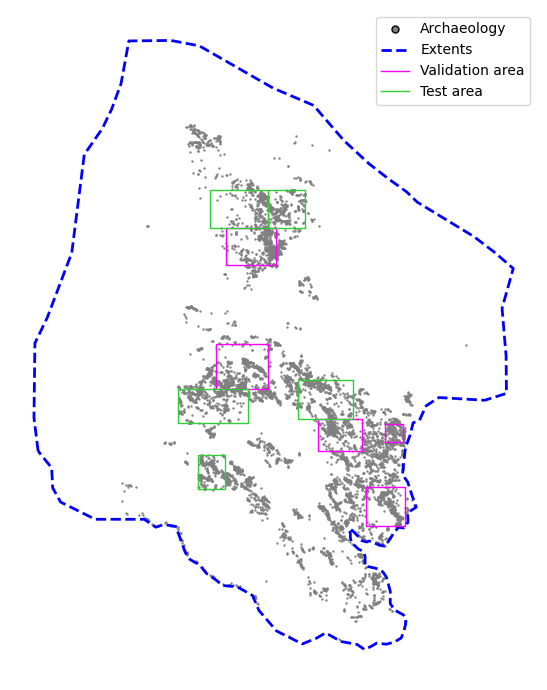

In [4]:
from matplotlib.lines import Line2D

# Load input data and visualize
gdf_extents = gpd.read_file(extents_file)
gdf_archaeology = gpd.read_file(archaeology_file)
gdf_split = gpd.read_file(split_file)

fig, ax = plt.subplots(1, 1, figsize=(7, 7)) 
gdf_archaeology.centroid.plot(color='gray', markersize=0.5, ax=ax)
gdf_extents.plot(facecolor="none", edgecolor='blue', linewidth=2, linestyle='--', ax=ax)
gdf_split[gdf_split["split"] == "validation"].plot(column='split', facecolor="none", edgecolor='magenta', linewidth=1, ax=ax)
gdf_split[gdf_split["split"] == "test"].plot(column='split', facecolor="none", edgecolor='limegreen', linewidth=1, ax=ax)

# Legend 
legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='gray', markersize=5, label='Archaeology'),
    Line2D([0], [0], color='blue', linestyle='--', linewidth=2, label='Extents'),
    Line2D([0], [0], color='magenta', linewidth=1, label='Validation area'),
    Line2D([0], [0], color='limegreen', linewidth=1, label='Test area'),
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True)

# Remove axis labels and ticks
ax.set_axis_off()

plt.tight_layout()
plt.show()


---

### Tile generation strategy

Tile generation differs slightly between dataset splits:

#### Training and validation

* Tiles are generated **only where positive archaeological samples are present**.
* As a result:

  * every training and validation tile contains at least some archaeology;
  * no purely background (negative-only) tiles are created in these subsets.

#### Test

* Tiles are generated exhaustively over the **entire bounding box** of the test areas, regardless of whether archaeology is present.
* This mirrors the behaviour of inference on unseen data.

> **Note**
> This design ensures that test evaluation reflects a realistic deployment scenario, where archaeology may or may not be present in any given tile.

---


### Create grid (tiles)

Running the following function will generate the tile grid for all three dataset splits (training, validation, and test).

> **Recommendation**
> It is strongly recommended to save the generated grid for future reference and reproducibility.



In [5]:
from adaf.create_singleclass_dataset import build_singleclass_segmentation_grids

tiles_gdf = build_singleclass_segmentation_grids(
    extents_gdf=gdf_extents,
    archaeology_gdf=gdf_archaeology,
    split_gdf=gdf_split,
    class_name="barrow",
    tile_size_px=512,
    overlap_px=256,
    pixel_size=0.5,
    split_field="split",
)

print(tiles_gdf["split"].value_counts().reindex(["training", "validation", "test"], fill_value=0))

split
training      4196
validation    1475
test          5407
Name: count, dtype: int64


In [6]:
# You can save the tiles to a vector file for later use
tiles_gdf.to_file(r"c:\Users\ncoz\Documents\STONE offline\learning_dataset_tiles.gpkg", driver="GPKG")  


### Output of the tile generation step

Using the three vector inputs listed above, the code generates a new vector layer `tiles_gdf` containing the **footprints of all learning tiles**.

The code automatically generates:
- the dataset split labels (*train / validation / test*).

---

## 2. Create visualisation



---

## 3. Create patches

The next step is to run the processing that creates the training patches.


**Requiered inputs**
* the visualisation raster `visualisation_ds_pth` created in **Section 2**
* the tile grid `tiles_gdf` created in **Step 1**

The only additional requirement is to specify the output location where the learning dataset will be saved. We will use the root folder `output_folder` that was defined at the begining of the notebook.

If the tile grid `tiles_gdf` has already been created in a previous run, it can be loaded directly from disk

```python
tiles_gdf = gpd.read_file(r"<path/to/file.gpkg>")
```

Before we start making ML patches, we need to generate file paths (in `tiles_gdf`) for saving the image tiles and their corresponding segmentation masks.

In [ ]:
# Optional import of tiles, if we have them saved in a vector file

import geopandas as gpd

tiles_gdf = gpd.read_file(r"c:\Users\ncoz\Documents\STONE offline\learning_dataset_tiles.gpkg")

In [9]:
from adaf.create_singleclass_dataset import add_image_and_mask_paths

# Location to which we want to save learning data
output_directory = r"c:\Users\ncoz\Documents\STONE offline\learning_ds"

# Name of the "project" - recommend using the stem of the input raster name (for example: ALS_stone_2025.vrt -> ALS_stone_2025)
ds_name = "ALS_stone_2025"

tiles_gdf = add_image_and_mask_paths(
    tiles_gdf,
    output_root=output_directory,
    ds_name=ds_name
)

print("Example of save paths for image and mask:")
print(tiles_gdf.iloc[0]["images_path"])
print(tiles_gdf.iloc[0]["segmentation_masks_path"])

Example of save paths for image and mask:
c:/Users/ncoz/Documents/STONE offline/learning_ds/training/images/254080_4752000__ALS_stone_2025__images.tif
c:/Users/ncoz/Documents/STONE offline/learning_ds/training/segmentation_masks/254080_4752000__ALS_stone_2025__segmentation_masks.tif



---

At this point, all required inputs are prepared and the workflow is ready to proceed with cutting out image patches and generating the corresponding segmentation masks using `create_patches_from_tiles`.

Requiered inputs are:
- `tiles_gdf` - tiles with paths for saving learning samples
- `gdf_archaeology` - vector with archaeological labels, defined at the beginning of the notebook
- `input_raster` - calculated ML ready visulaisation
- `arch_type` - segmentation class
- `dfm_value` - in our case DFM is uniform for the entire dataset and is set to 1 (IMPORTANT for the ADAF dataloader!)


In [ ]:
# Additional requiered parameters

input_raster = r"r:\delovno\nejc\stone_visualisations\BiH_ALS_2025_DMO_05m_slrm4inference.vrt"

In [ ]:
# Create patches

from adaf.create_singleclass_dataset import create_patches_from_tiles

proc_res = create_patches_from_tiles(
    gdf_tiles=tiles_gdf,
    gdf_archaeology=gdf_archaeology,
    input_raster=input_raster,
    arch_type="barrow",
    dfm_value=1
)

---

## Summary and conclusion

TODO: Write down what we end up with and how to then continue with trainning